In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from multiprocessing import Pool
from sklearn.linear_model import LinearRegression
import matplotlib.patches as mpatches

In [2]:
signal_list  = [
    "B0_st",
    "cas_q_hl_32",
    "cas_c_hh_12",
    "lambcs_bc_32"
]

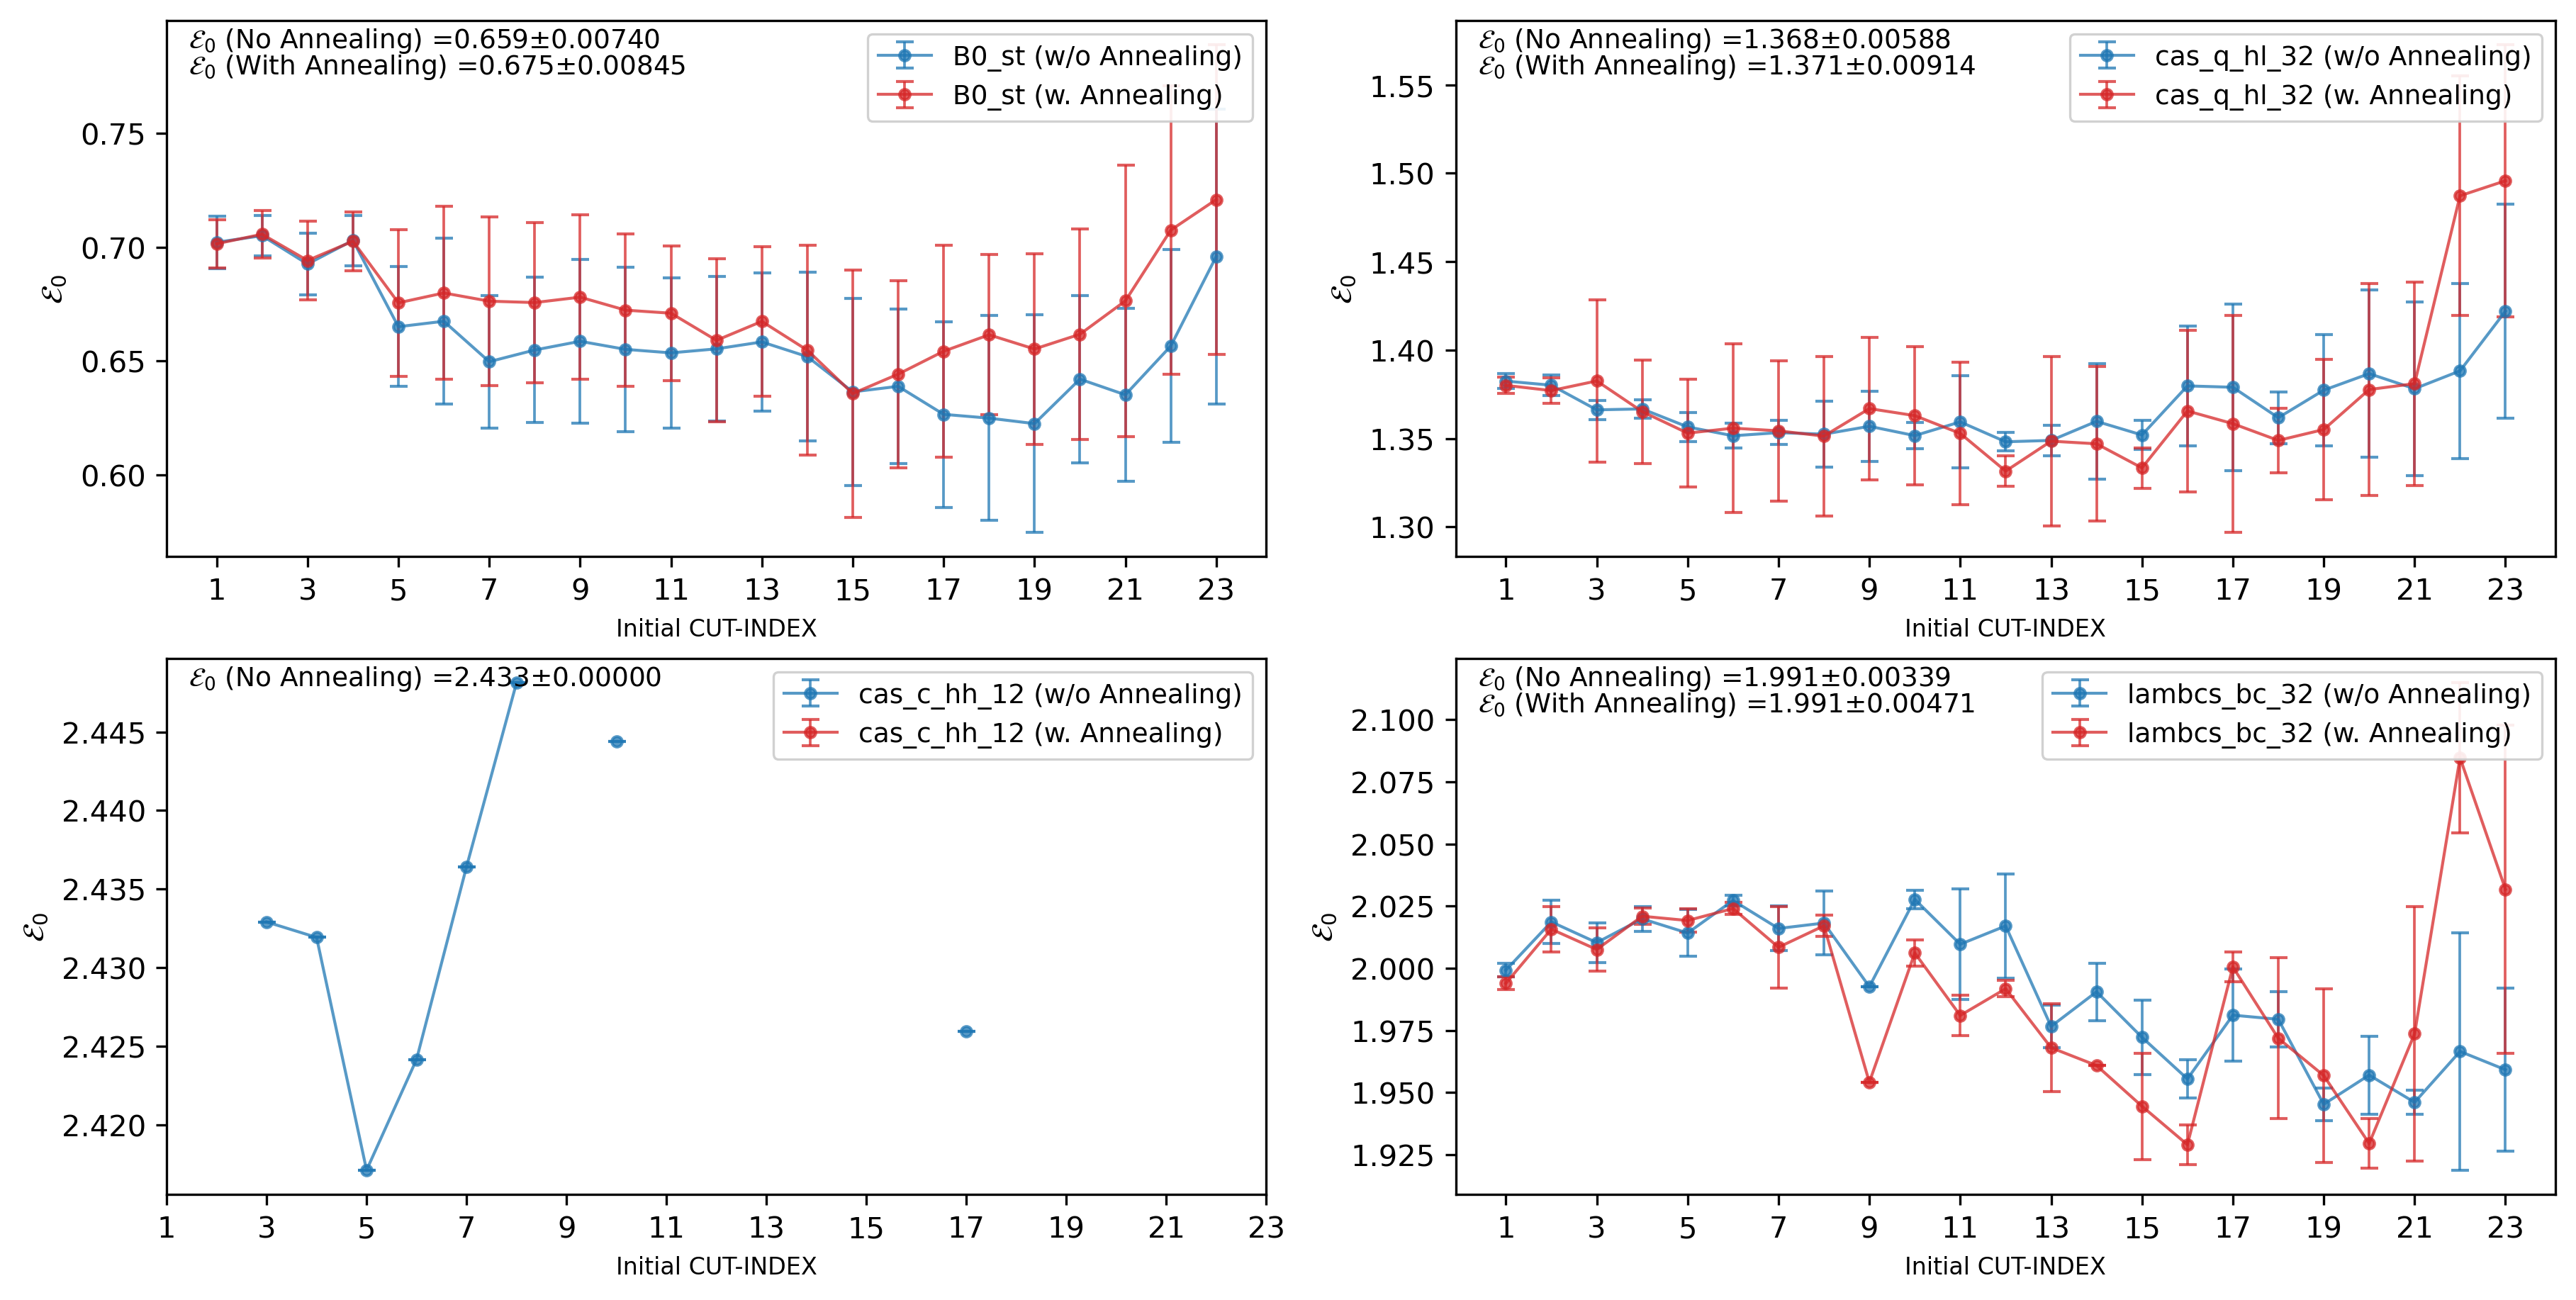

In [58]:
signals = signal_list
n_panels = 4

groups = [signals[i::n_panels] for i in range(n_panels)]

fig, axes = plt.subplots(2, 2, figsize=(12, 6), dpi=300, constrained_layout=True)
axes = axes.ravel()

colors = ["tab:blue", "tab:orange"]

bands = {
    0: [0, 3],
    1: [0, 12],          
    2: [0, 10], 
    3: [0, 5] 
}

energy = {
    0:[0.695,0.715],
    1:[1.35,1.32],
    2:[2.4,2.45],
    3:[2.015,2.039],
}


for ax_idx, ax in enumerate(axes):
    handles = []
    for signal in groups[ax_idx]:
        y_mean_GD = np.load(f"./results_GD/{signal}_GD_mean.npy")
        y_std_GD  = np.load(f"./results_GD/{signal}_GD_std.npy")

        y_mean_GDA = np.load(f"./results_GDA/{signal}_GDA_mean.npy")
        y_std_GDA  = np.load(f"./results_GDA/{signal}_GDA_std.npy")

        
        h = ax.errorbar(np.arange(0,y_mean_GD.shape[0]), y_mean_GD, yerr=y_std_GD,
            fmt="o-", capsize=3, linewidth=1.0, elinewidth=0.9,
            markersize=3.5, alpha=0.75, label=signal + " (w/o Annealing)",color = "tab:blue")

        h1 = ax.errorbar(np.arange(0,y_mean_GDA.shape[0]), y_mean_GDA, yerr=y_std_GDA,
            fmt="o-", capsize=3, linewidth=1.0, elinewidth=0.9,
            markersize=3.5, alpha=0.75, label=signal + " (w. Annealing)",color = "tab:red")
       
        handles.append(h)
        handles.append(h1)

        y_mean_GD = y_mean_GD[~np.isnan(y_mean_GD)]
        y_mean_GDA = y_mean_GDA[~np.isnan(y_mean_GDA)]
        y_std_GD = y_std_GD[~np.isnan(y_std_GD)]
        y_std_GDA = y_std_GDA[~np.isnan(y_std_GDA)]
        
        if y_mean_GD.shape[0] !=0:
            mean_energy_GD = np.array(y_mean_GD).mean()
            std_error_GD = np.sum(np.array(y_std_GD)**2)**0.5/len(y_std_GD)
            ax.text(0.02, 0.99, (r"$\mathcal{E}_0$ (No Annealing) ="+f"{mean_energy_GD:.3f}"+r"$\pm$"f"{std_error_GD:.5f}"), transform=ax.transAxes,ha="left", va="top", fontsize=9)
        if y_mean_GDA.shape[0] !=0:
            mean_energy_GDA = np.array(y_mean_GDA).mean()
            std_error_GDA = np.sum(np.array(y_std_GDA)**2)**0.5/len(y_std_GDA)
            ax.text(0.02, 0.94, (r"$\mathcal{E}_0$ (With Annealing) ="+f"{mean_energy_GDA:.3f}"+r"$\pm$"f"{std_error_GDA:.5f}"), transform=ax.transAxes,ha="left", va="top", fontsize=9)


    ax.set_xticks(np.arange(0,23)[::2])
    ax.set_xticklabels((np.arange(0,23)[::2]+1).tolist())

    ax.set_xlabel("Initial CUT-INDEX", fontsize=8)
    ax.set_ylabel(r"$\mathcal{E}_0$", fontsize=10)


    if handles:
        leg = ax.legend(loc="upper right", frameon=True, ncol=1,fontsize=9)
        leg.get_frame().set_alpha(0.9)
        leg.get_frame().set_linewidth(0.8)
plt.savefig("../assets/Annealing01.png")
plt.show()
